# Research Question 2: Mobilization vs. Persuasion in Pennsylvania's Democratic Decline (2020–2024)

Analysis workflow: build a county-level typology, test the turnout/vote-share relationship statistically, identify residual outlier counties, and plot the result.

## 1. Imports and data load

Loads the same 67-county Pennsylvania dataset built for Question 1.

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
import statsmodels.formula.api as smf
import plotly.graph_objects as go

# Same county-level dataset built for Question 1 (67 PA counties)
df = pd.read_csv("C:/Users/mutch/Democratic_Voter_Shift/data/processed/election_f_numchange.csv")
df.head()

,Unnamed: 0.1,Unnamed: 0,county,countyfips,statepo,demvoteshare_2020,demvoteshare_2024,gopvoteshare_2020,gopvoteshare_2024,totalvotes_2020,totalvotes_2024,turnoutrate_2020,turnoutrate_2024,demvoteshare_change,gopvoteshare_change,turnout_change,ruralurban,dem_change,gop_change
0,0,0,Adams,42001,PA,0.322020,0.327156,0.663654,0.663611,56540,60650,0.781069,0.797942,0.005136,-0.000043,0.016874,rural,1635.0,2725.0
1,1,1,Allegheny,42003,PA,0.596145,0.596688,0.392262,0.393606,719733,720504,0.763840,0.756400,0.000543,0.001344,-0.007440,urban,851.0,1271.0
2,2,2,Armstrong,42005,PA,0.232527,0.230421,0.755815,0.762305,36370,37119,0.811359,0.830942,-0.002106,0.006490,0.019582,rural,96.0,807.0
3,3,3,Beaver,42007,PA,0.405028,0.392185,0.581787,0.599275,94122,94843,0.804799,0.807532,-0.012843,0.017487,0.002733,urban,-926.0,2078.0
4,4,4,Bedford,42009,PA,0.158374,0.153977,0.835026,0.840128,27574,28160,0.805339,0.833111,-0.004397,0.005102,0.027773,rural,-31.0,633.0


## 2. Quartile thresholds for the typology

"Large decline" / "large gain" are defined relative to each variable's own distribution (quartile-based), not a fixed cutoff. This keeps the typology comparable across variables with very different scales.

In [2]:
q1_t, med_t, q3_t = df["turnout_change"].quantile([0.25, 0.5, 0.75])
q1_v, med_v, q3_v = df["demvoteshare_change"].quantile([0.25, 0.5, 0.75])

print("turnout_change      Q1 / median / Q3:", q1_t, med_t, q3_t)
print("demvoteshare_change Q1 / median / Q3:", q1_v, med_v, q3_v)

turnout_change      Q1 / median / Q3: 0.0006472475 0.0081849 0.020629011
demvoteshare_change Q1 / median / Q3: -0.013784227999999999 -0.006125302 0.0017077504999999998


## 3. Classify each county's turnout and vote-share status

`turnout_status` flags counties in the bottom quartile as "decline" and top quartile as "increase"; everything in between is "stable". `voteshare_status` does the same but labels the bottom quartile "large_decline" and top quartile "gain".

In [3]:
def turnout_status(x):
    if x <= q1_t:
        return "decline"
    elif x > q3_t:
        return "increase"
    return "stable"

def voteshare_status(x):
    if x <= q1_v:
        return "large_decline"
    elif x > q3_v:
        return "gain"
    return "stable"

df["turnout_status"] = df["turnout_change"].apply(turnout_status)
df["voteshare_status"] = df["demvoteshare_change"].apply(voteshare_status)

## 4. Build the 5-category mobilization/persuasion typology

This is the operational test of H2. A county only counts as "Mobilization-Driven" or "Persuasion-Driven" if ONE mechanism shows a large decline while the other stays stable/positive. "Mixed" requires both to show large decline at once. Anything with a vote-share gain is "Resilient / Gain" regardless of turnout. Everything else falls into a residual "Minimal Change" bucket (this is an extension beyond the original 4-way framing).

In [4]:
def classify(row):
    t, v = row["turnout_status"], row["voteshare_status"]
    if v == "gain":
        return "Resilient / Gain"
    if t == "decline" and v == "large_decline":
        return "Mixed (Mobilization + Persuasion)"
    if t == "decline" and v == "stable":
        return "Mobilization-Driven Decline"
    if t in ("stable", "increase") and v == "large_decline":
        return "Persuasion-Driven Decline"
    return "Minimal Change / Ambiguous"

df["typology"] = df.apply(classify, axis=1)

# Group sizes and mean turnout/vote-share change per category (feeds Table 1)
summary = df.groupby("typology").agg(
    n=("county", "size"),
    mean_turnout_change=("turnout_change", "mean"),
    mean_demvoteshare_change=("demvoteshare_change", "mean"),
).round(4)
summary

,n,mean_turnout_change,mean_demvoteshare_change
typology,,,
Minimal Change / Ambiguous,26,0.0217,-0.0062
Mixed (Mobilization + Persuasion),6,-0.0131,-0.0225
Mobilization-Driven Decline,7,-0.0078,-0.0054
Persuasion-Driven Decline,11,0.0123,-0.0205
Resilient / Gain,17,0.0262,0.0041


## 5. Correlation between turnout change and vote-share change

Pearson tests the linear relationship; Spearman is a robustness check using ranks (less sensitive to outlier counties like Philadelphia).

In [5]:
r, p_r = pearsonr(df["turnout_change"], df["demvoteshare_change"])
rho, p_rho = spearmanr(df["turnout_change"], df["demvoteshare_change"])

print(f"Pearson r = {r:.4f}, p = {p_r:.4f}")
print(f"Spearman rho = {rho:.4f}, p = {p_rho:.4f}")

Pearson r = 0.2744, p = 0.0247
Spearman rho = 0.2212, p = 0.0721


## 6. OLS regression (with and without rural/urban covariate)

Model 1 is the bivariate regression underlying H2's continuous test. Model 2 adds a rural/urban categorical covariate to see whether geography absorbs some of the "unexplained" variance in vote-share change.

In [6]:
model1 = smf.ols("demvoteshare_change ~ turnout_change", data=df).fit()
print(model1.summary())

df["ruralurban"] = df["ruralurban"].astype("category")
model2 = smf.ols("demvoteshare_change ~ turnout_change + C(ruralurban)", data=df).fit()
print(model2.summary())

                             OLS Regression Results                            
Dep. Variable:     demvoteshare_change   R-squared:                       0.075
Model:                             OLS   Adj. R-squared:                  0.061
Method:                  Least Squares   F-statistic:                     5.291
Date:                 Fri, 17 Jul 2026   Prob (F-statistic):             0.0247
Time:                         18:11:11   Log-Likelihood:                 216.18
No. Observations:                   67   AIC:                            -428.4
Df Residuals:                       65   BIC:                            -424.0
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -0.0089      0.0

## 7. Residual outliers (persuasion-dominant vs. resilient counties)

Residuals from Model 1 show which counties' actual vote-share change deviates most from what `turnout_change` alone would predict. Large negative residuals = lost more Democratic support than turnout explains (persuasion loss). Large positive residuals = held up better than turnout predicts.

In [7]:
df["resid_model1"] = model1.resid

print("Largest negative residuals (persuasion-dominant losses):")
print(df.nsmallest(6, "resid_model1")[["county", "resid_model1"]])

print("\nLargest positive residuals (resilient beyond turnout):")
print(df.nlargest(6, "resid_model1")[["county", "resid_model1"]])

Largest negative residuals (persuasion-dominant losses):
          county  resid_model1
44        Monroe     -0.025973
39       Luzerne     -0.019165
34    Lackawanna     -0.017833
51          Pike     -0.016418
50  Philadelphia     -0.016337
38        Lehigh     -0.015086

Largest positive residuals (resilient beyond turnout):
        county  resid_model1
56    Sullivan      0.016693
59       Union      0.015585
49       Perry      0.015503
0        Adams      0.012269
27    Franklin      0.012041
20  Cumberland      0.012036


## 8. Quadrant scatterplot (Figure 6)

Jitter is applied only to marker position (for label readability with 67 overlapping counties) — true values are preserved in the hover tooltip. Dashed lines mark the same quartile thresholds used to build the typology.

C:\Users\mutch\AppData\Local\Temp\ipykernel_17724\1170464353.py:68: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  pio.write_image(fig, "C:/Users/mutch/Democratic_Voter_Shift/output/persuation.png", format="png")


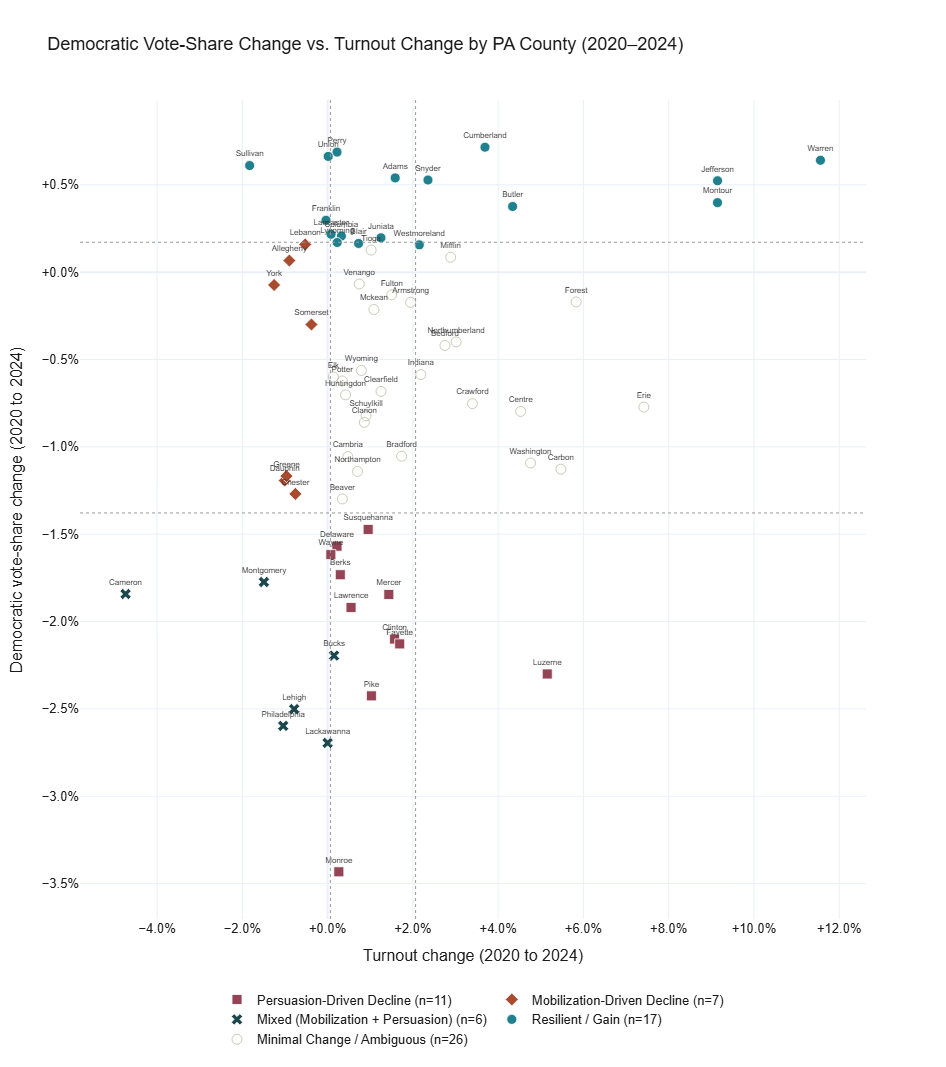

In [11]:
np.random.seed(11)
jitter_frac = 0.01
x_range = df["turnout_change"].max() - df["turnout_change"].min()
y_range = df["demvoteshare_change"].max() - df["demvoteshare_change"].min()
df["x_jit"] = df["turnout_change"] + np.random.uniform(-jitter_frac, jitter_frac, len(df)) * x_range
df["y_jit"] = df["demvoteshare_change"] + np.random.uniform(-jitter_frac, jitter_frac, len(df)) * y_range

color_map = {
    "Mobilization-Driven Decline": "#A84B2F",
    "Persuasion-Driven Decline": "#944454",
    "Mixed (Mobilization + Persuasion)": "#1B474D",
    "Resilient / Gain": "#20808D",
    "Minimal Change / Ambiguous": "#BEBCA6",
}
symbol_map = {
    "Mobilization-Driven Decline": "diamond",
    "Persuasion-Driven Decline": "square",
    "Mixed (Mobilization + Persuasion)": "x",
    "Resilient / Gain": "circle",
    "Minimal Change / Ambiguous": "circle-open",
}
category_order = [
    "Persuasion-Driven Decline",
    "Mobilization-Driven Decline",
    "Mixed (Mobilization + Persuasion)",
    "Resilient / Gain",
    "Minimal Change / Ambiguous",
]

fig = go.Figure()
for cat in category_order:
    sub = df[df["typology"] == cat]
    fig.add_trace(go.Scatter(
        x=sub["x_jit"], y=sub["y_jit"],
        mode="markers+text",
        name=f"{cat} (n={len(sub)})",
        text=sub["county"],
        textposition="top center",
        textfont=dict(size=8, color="#333333", family="Arial"),
        marker=dict(size=10, color=color_map[cat], symbol=symbol_map[cat],
                    line=dict(width=0.8, color="white")),
        customdata=np.stack([sub["turnout_change"], sub["demvoteshare_change"]], axis=-1),
        hovertemplate=(
            "County: %{text}<br>"
            "Turnout change: %{customdata[0]:.2%}<br>"
            "Dem vote-share change: %{customdata[1]:.2%}<br>"
            f"Typology: {cat}<extra></extra>"
        ),
    ))

for xv in [q1_t, q3_t]:
    fig.add_vline(x=xv, line_dash="dot", line_color="#999999", line_width=1)
for yv in [q1_v, q3_v]:
    fig.add_hline(y=yv, line_dash="dot", line_color="#999999", line_width=1)

fig.update_layout(
    title="Democratic Vote-Share Change vs. Turnout Change by PA County (2020–2024)",
    template="plotly_white",
    width=1400, height=1050,
    font=dict(family="Arial", size=13, color="#1a1a1a"),
    legend=dict(orientation="h", y=-0.08, xanchor="center", x=0.5),
)
fig.update_xaxes(title_text="Turnout change (2020 to 2024)", tickformat="+.1%")
fig.update_yaxes(title_text="Democratic vote-share change (2020 to 2024)", tickformat="+.1%")

# your Plotly figure
import plotly.io as pio
pio.write_image(fig, "C:/Users/mutch/Democratic_Voter_Shift/output/persuation.png", format="png")

fig.show()


